In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import time

import torch
import numpy as np

from matplotlib import pyplot as plt

import kind
import utils_plot


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                144        1
   valid     1000                144        1
    test      500                144        1



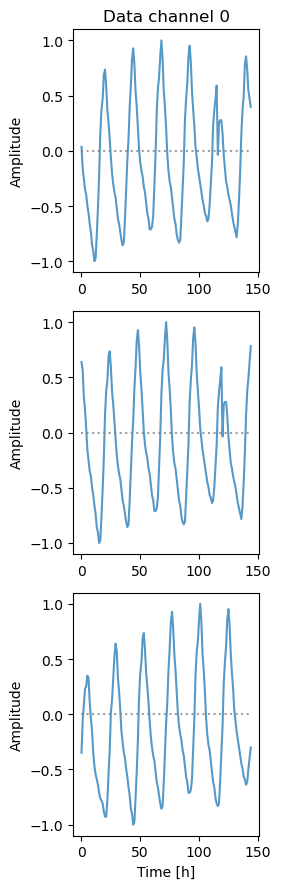

In [2]:
# --! display transient dataset --!

datadir               = '../../data/baselines/et_train_stat'
timeseries_ndim       = 1
timeseries_nsample    = 144
timestep              = 3600

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=3)


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                144        1
   valid     1000                144        1
    test      500                144        1



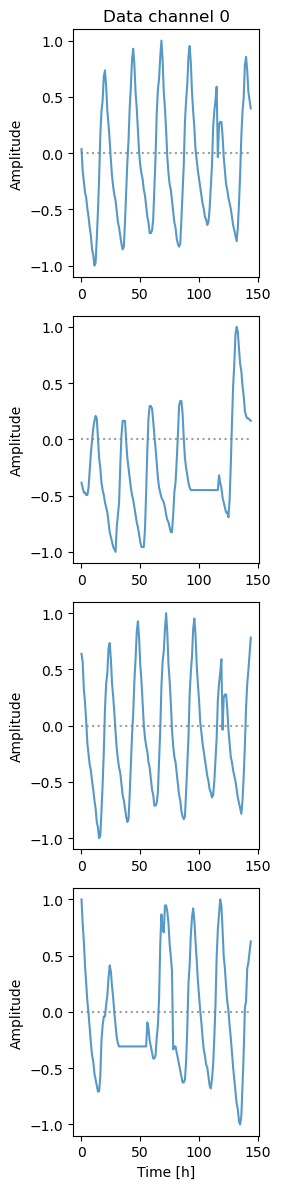

In [3]:
# --! display transient dataset --!

datadir               = '../../data/baselines/et_train_mixed'
timeseries_ndim       = 1
timeseries_nsample    = 144
timestep              = 3600

utils_plot.plot_dataset(datadir, timeseries_nsample, timestep, plot_ndata=4)

In [4]:
# --! recreate a model --!

# --! ensure reproducible results
seed = 2025
torch.manual_seed(seed)

forecast_nsample = 48
lookback_nsample = timeseries_nsample - forecast_nsample

model_cfg = kind.model_config(

    timeseries_ndim    = timeseries_ndim,
    timestep           = timestep,
    lookback_nsample   = lookback_nsample,
    forecast_nsample   = forecast_nsample,

    fun_stat = {
        'sin'   : 4,
        'cos'   : 4,
    },

    fun_trans = {
        'data'   : 10,
    },

    param_kernsize_stat  = 12,
    param_kernsize_trans = 24,

    mean_att_used = True,
    var_att_used  = False,
)

model = kind.model(model_cfg)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {model_size / 1e6:.2f}M')

Total trainable parameters: 0.27M


In [5]:
# --! train the model --!

model.train()

# --! number of timeseries in one batch
batsize = 128

trainparam = {
    'stadatadir'            : '../../data/baselines/et_train_stat',
    'transdatadir'          : '../../data/baselines/et_train_trans',
    'mixdatadir'            : '../../data/baselines/et_train_mixed',
    'timeseries_nsample'    : timeseries_nsample,
    'train_nfile'           : 7,
    'batsize'               : batsize,
    'nepoch'                : 100,
    'isverbose'             : True,
    'learnrate'             : 1e-3,
    'weightdecay'           : 1e-4,
}

loss = []

t_start = time.time()
#loss.append(model.fit(trainparam))
#model.fit_next()
#model.fit(trainparam)
while True:
    loss.append(model.fit(trainparam))
    if not model.fit_next():
        break

t_end     = time.time()
t_elapsed = t_end - t_start
print(f'inf >> training time elapsed: {t_elapsed:.1f} seconds')

inf >> fit: entering stationary mean phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> exiting stationary mean phase

inf >> fit details:

  batch size   time per iteration [s]
  ----------   ----------------------
         128                  6.5e-03

inf >> fit: entering stationary variance phase
inf >> number of data files for training is 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7
inf >> exiting stationary variance phase

inf >> fit details:

  batch

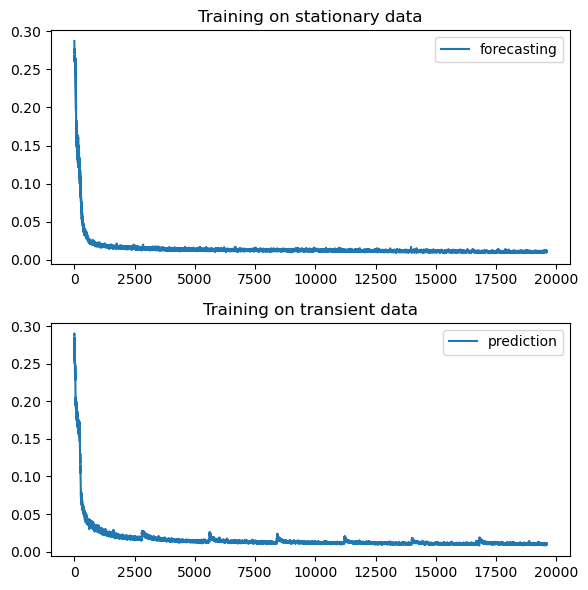

In [6]:
# --! plot training statistics --!

with torch.no_grad():
    loss_stat_mean = loss[0]
    loss_trans     = loss[2]

    plt.figure(figsize=(6, 6))

    plt.subplot(2, 1, 1)
    plt.title('Training on stationary data')
    plt.plot(loss_stat_mean[0], label='forecasting')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.title('Training on transient data')
    plt.plot(loss_trans[0], label='prediction')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=192, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=768, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_me

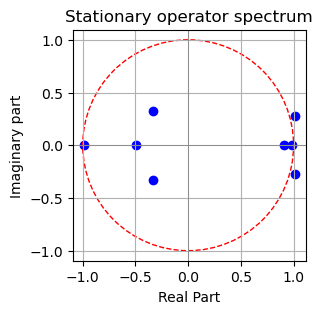

tensor([-0.9917+0.0000j, -0.4908+0.0000j, -0.3339+0.3277j, -0.3339-0.3277j,
         1.0130+0.2740j,  1.0130-0.2740j,  0.9877+0.0000j,  0.9052+0.0000j])


In [8]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

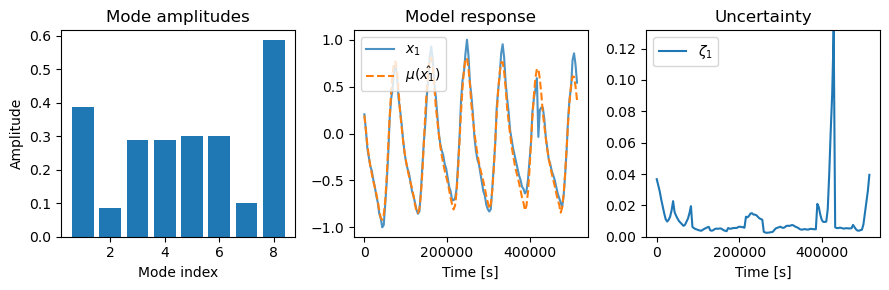

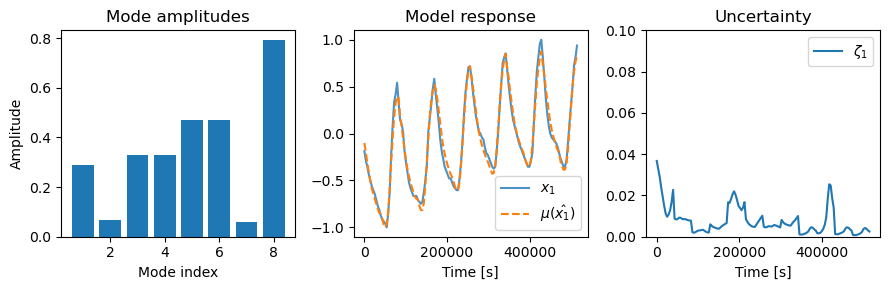

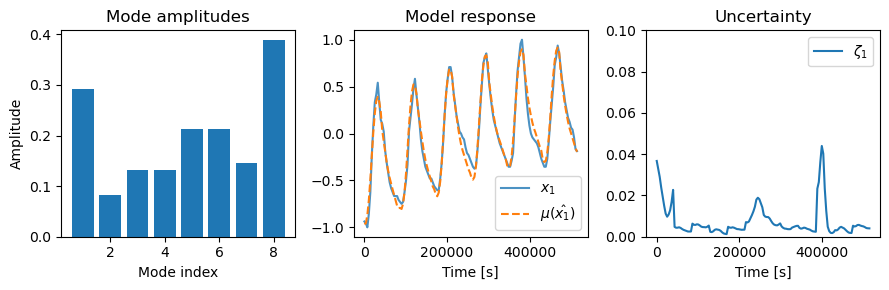

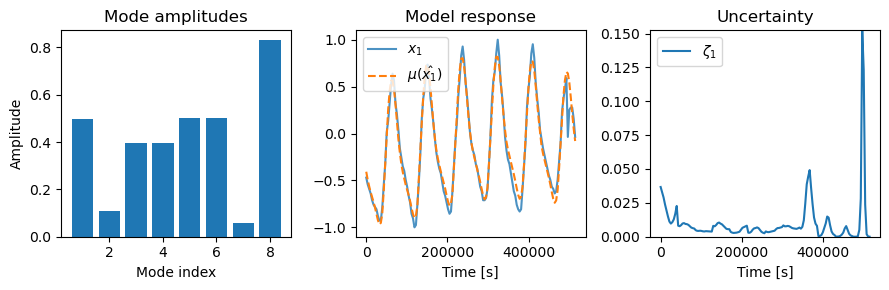

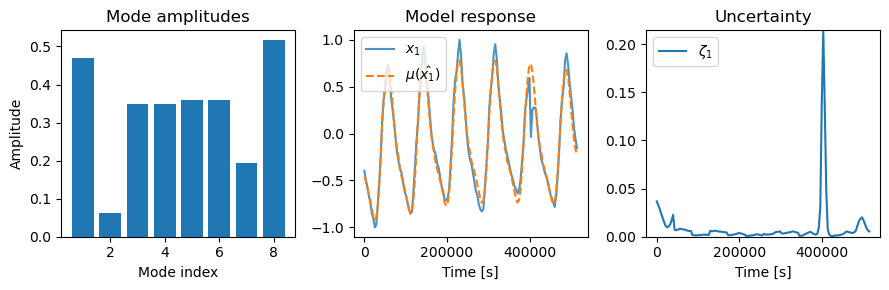

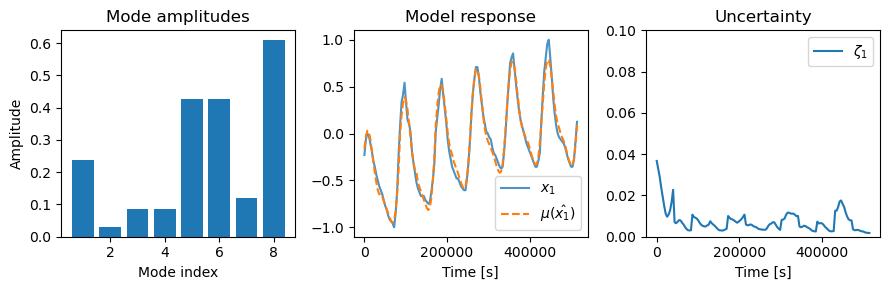

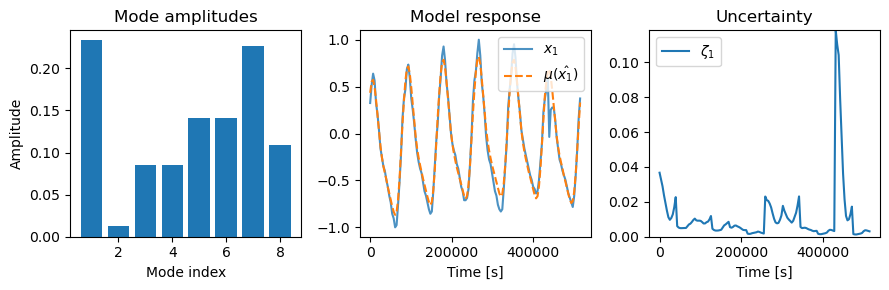

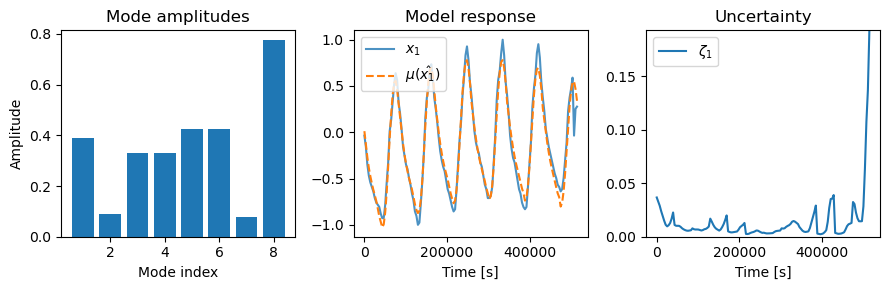

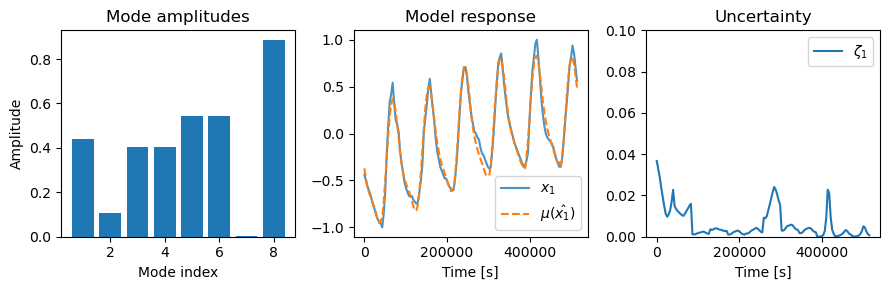

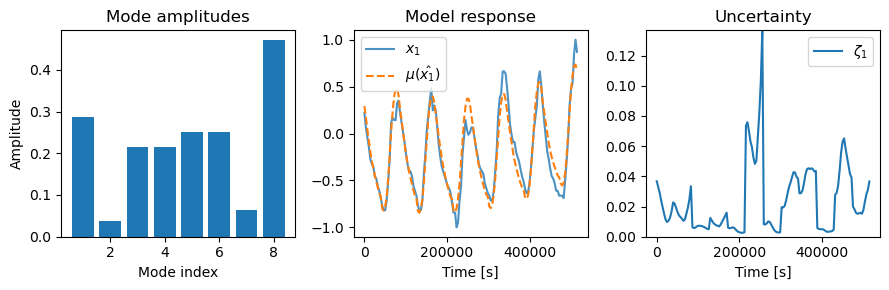

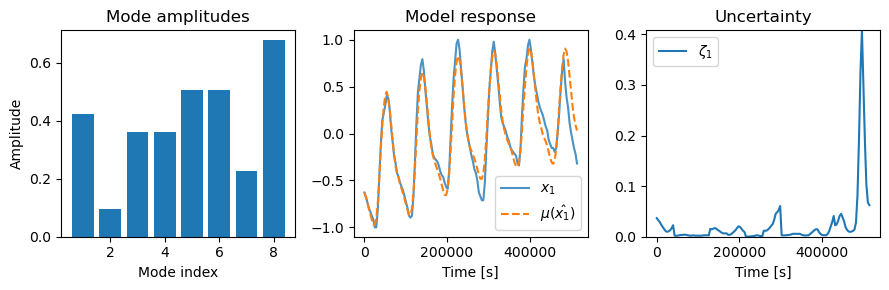

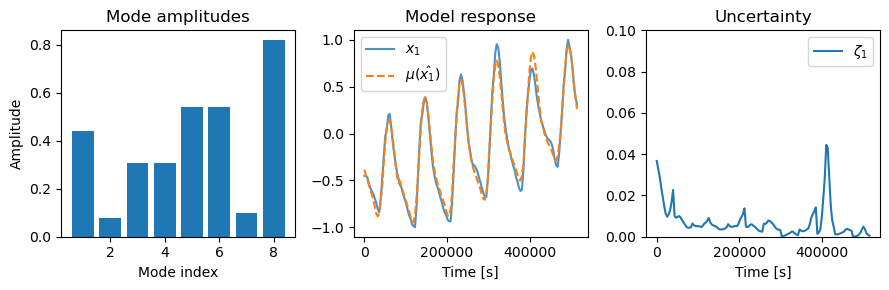

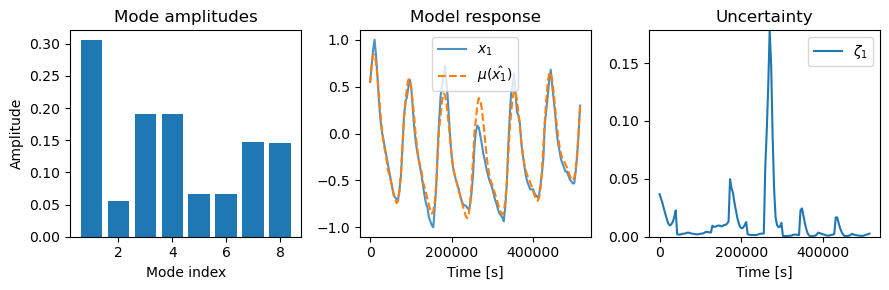

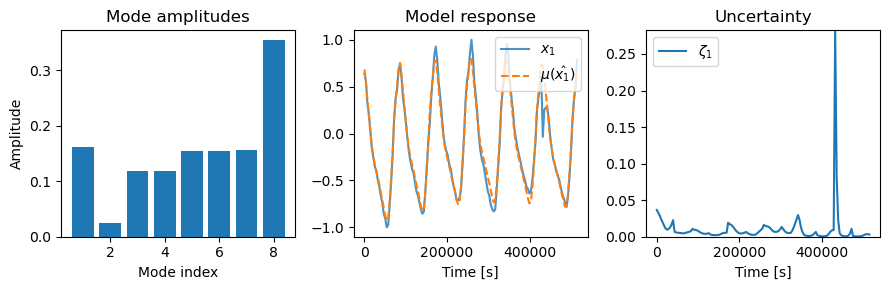

In [9]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/et_train_stat'
timeseries_nsample = 144

with torch.no_grad():
    for jtimeseries in range(14):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

In [10]:
# --! save the trained model --!

modelsaved = True

if modelsaved:
    torch.save(model, '../../models/baselines/et_kind.pt')